In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn.datasets
from sklearn.model_selection import train_test_split

In [ ]:
from tensorflow import keras as kr
from tensorflow.keras import layers,models,datasets

In [ ]:
d=kr.datasets.mnist
(x_train,y_train),(x_test,y_test)=d.load_data()
x_train,x_test=x_train/255.0,x_test/255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:

from tensorflow.keras import Input, models
from tensorflow.keras.layers import LSTM, Dense, Bidirectional

In [ ]:
input_shape = (28, 28)
inputs = Input(shape=input_shape)
rnn = Bidirectional(LSTM(128))(inputs)

In [ ]:
outputs = Dense(10, activation='softmax')(rnn)

model = models.Model(inputs=inputs, outputs=outputs)

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 256)            │       160,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 163,338 (638.04 KB)

 Trainable params: 163,338 (638.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer="adam",
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
model=model.fit(x_train,y_train,validation_split=0.1,epochs=10)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 76s 44ms/step - accuracy: 0.8961 - loss: 0.3238 - val_accuracy: 0.9687 - val_loss: 0.1090
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 82s 44ms/step - accuracy: 0.9678 - loss: 0.1058 - val_accuracy: 0.9720 - val_loss: 0.0945
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 81s 43ms/step - accuracy: 0.9772 - loss: 0.0745 - val_accuracy: 0.9785 - val_loss: 0.0740
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 74s 44ms/step - accuracy: 0.9822 - loss: 0.0579 - val_accuracy: 0.9790 - val_loss: 0.0665
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 76s 45ms/step - accuracy: 0.9851 - loss: 0.0477 - val_accuracy: 0.9867 - val_loss: 0.0478
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 74s 44ms/step - accuracy: 0.9867 - loss: 0.0414 - val_accuracy: 0.9863 - val_loss: 0.0446
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 73s 43ms/step - accuracy: 0.9899 - loss: 0.0325 - val_accuracy: 0.9863 - val_loss: 0.0460
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 74s 44ms/step - accuracy: 0.9905 -

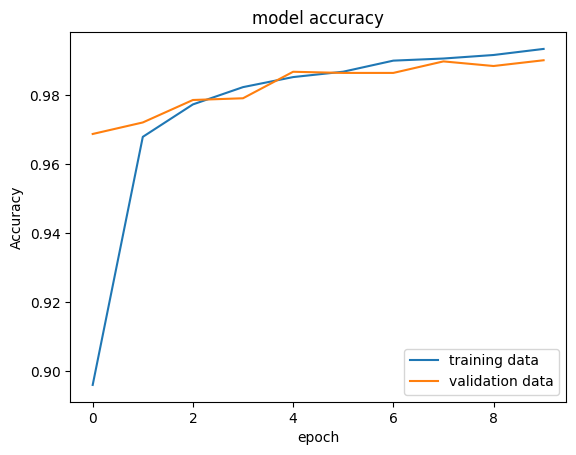

In [ ]:
plt.plot(model.history["accuracy"])
plt.plot(model.history['val_accuracy'])
plt.title("model accuracy")
plt.xlabel("epoch")
plt.ylabel("Accuracy")
plt.legend(['training data','validation data'],loc='lower right')

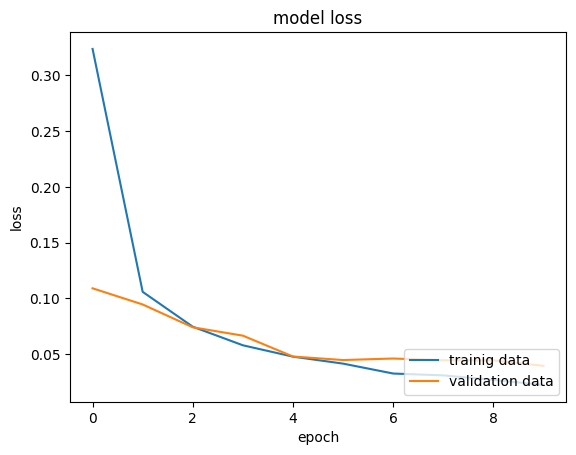

In [ ]:
plt.plot(model.history['loss'])
plt.plot(model.history['val_loss'])
plt.title("model loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend(['trainig data','validation data'],loc='lower right')